# EEG Motor Imagery Analysis — Left vs. Right Hand (PhysioNet EEGBCI)

**Subject 1**, imagined left- vs. right-fist movement. Pipeline: load → inspect →
filter & clean (ICA) → epoch → ERD/ERS → CSP+LDA decoding (static & time-resolved) → summary.

In [38]:
from pathlib import Path

import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.datasets import eegbci

mne.set_log_level('WARNING')

# Consistent, presentation-quality plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'legend.frameon': False,
    'figure.dpi': 100,
})
PRIMARY_COLOR = '#2c7fb8'
ACCENT_COLOR = '#d95f02'

# All figures are saved to disk as well as displayed inline
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, filename, dpi=150):
    """Save a Figure to FIG_DIR. Some MNE plot functions return a list of
    Figures (one per page) instead of a single Figure -- handle both."""
    if isinstance(fig, (list, tuple)):
        fig = fig[0]
    fig.savefig(FIG_DIR / filename, dpi=dpi, bbox_inches='tight')

## 1. Data Loading

In [39]:
# Runs 4, 8, 12 = motor IMAGERY, left vs. right fist (T1 = left, T2 = right).
# Run 14 is intentionally excluded: it belongs to a different task (imagined
# both-fists vs. both-feet) that reuses the T1/T2 labels for a different
# meaning -- mixing it in would silently corrupt the binary classification
# performed later in this notebook.
SUBJECT = 1
RUNS = [4, 8, 12]

raw_fnames = eegbci.load_data(SUBJECT, RUNS)
raws = [mne.io.read_raw_edf(f, preload=True) for f in raw_fnames]
raw = mne.concatenate_raws(raws)

eegbci.standardize(raw)
montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage)

<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>

## 2. Data Overview

In [40]:
print(raw.info)
print(f"\nRecording duration : {raw.times[-1]:.1f} s ({raw.times[-1]/60:.1f} min)")
print(f"Sampling rate      : {raw.info['sfreq']:.0f} Hz")
print(f"Channels ({len(raw.ch_names)}): {', '.join(raw.ch_names[:10])} ...")

<Info | 9 non-empty values
 bads: []
 ch_names: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

Recording duration : 375.0 s (6.2 min)
Sampling rate      : 160 Hz
Channels (64): FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1 ...


## 3. Raw Signal

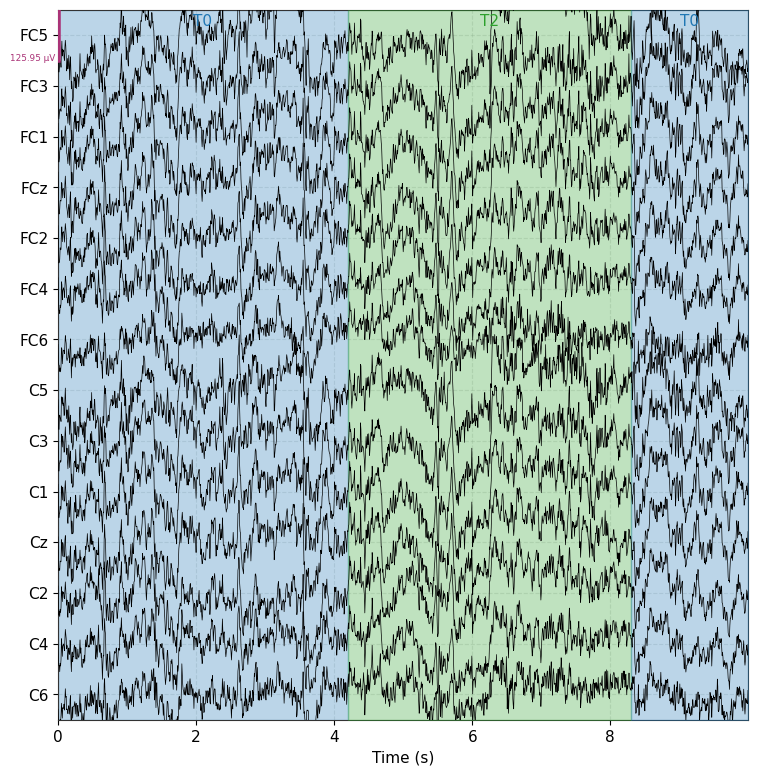

In [41]:
motor_picks = ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6',
               'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6']

# Raw.plot() renders itself immediately (show=True by default) -- do not
# also call plt.show() here, or the figure is drawn twice.
raw_fig = raw.plot(duration=10, n_channels=14, picks=motor_picks,
                    scalings='auto', title='Raw EEG — Motor Channels (first 10 s)',
                    show_scrollbars=False)
save_fig(raw_fig, 'raw_timeseries.png')

## 4. Spectral Content (PSD)

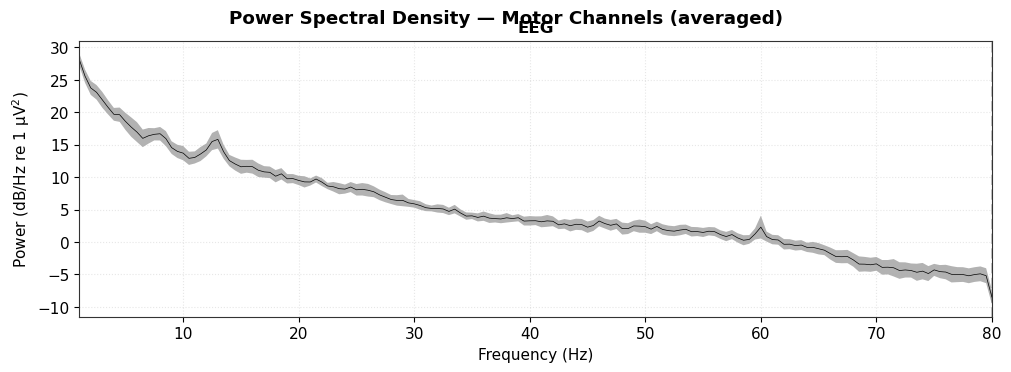

In [42]:
# The mu (8-12 Hz) and beta (13-30 Hz) bands are the physiological
# signatures of motor imagery we care about below.
psd_fig = raw.compute_psd(method='welch', fmin=1, fmax=80,
                           n_fft=int(raw.info['sfreq'] * 2),  # 2-second windows
                           picks=motor_picks).plot(average=True, amplitude=False, show=False)
psd_fig.suptitle('Power Spectral Density — Motor Channels (averaged)', y=1.02, fontweight='bold')
save_fig(psd_fig, 'psd_welch_motor.png')
plt.show()

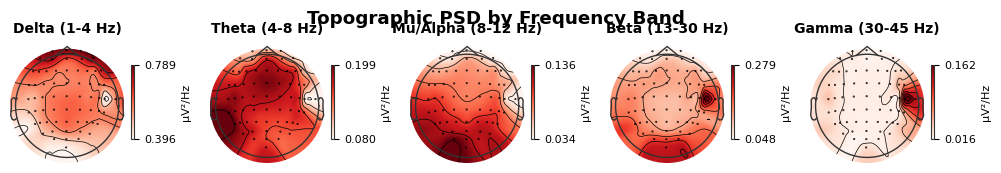

In [43]:
bands = {
    'Delta (1-4 Hz)':     (1, 4),
    'Theta (4-8 Hz)':     (4, 8),
    'Mu/Alpha (8-12 Hz)': (8, 12),
    'Beta (13-30 Hz)':    (13, 30),
    'Gamma (30-45 Hz)':   (30, 45),
}

topo_fig = raw.compute_psd(method='welch', fmin=1, fmax=45).plot_topomap(
    bands=bands, ch_type='eeg', normalize=True, show=False)
topo_fig.suptitle('Topographic PSD by Frequency Band', y=1.05, fontweight='bold')
save_fig(topo_fig, 'psd_topomap_bands.png')
plt.show()

## 5. Preprocessing: Filtering, Bad-Channel Screening, ICA

In [44]:
raw_filt = raw.copy().filter(l_freq=0.5, h_freq=40.0, fir_design='firwin')

Outlier channels are screened with a robust (MAD-based) modified z-score of
per-channel standard deviation, computed on the filtered signal -- a fixed
µV peak-to-peak threshold on unfiltered data flags almost every channel due
to slow drift, so it is not a useful criterion here.

In [45]:
eeg_data = raw_filt.get_data(picks='eeg')
ch_names = raw_filt.copy().pick('eeg').ch_names

ch_std = eeg_data.std(axis=1)
median_std = np.median(ch_std)
mad = np.median(np.abs(ch_std - median_std))
modified_z = 0.6745 * (ch_std - median_std) / (mad + 1e-12)

bads = [ch for ch, z in zip(ch_names, modified_z) if abs(z) > 3.5]
raw_filt.info['bads'] = bads

print(f"Flagged {len(bads)} channel(s) as outliers: {bads or 'none'}")
if bads:
    raw_filt.interpolate_bads(reset_bads=True)
    print("Interpolated the flagged channel(s) using spherical splines.")

Flagged 9 channel(s) as outliers: ['Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'FT8', 'T8', 'T10', 'TP8']
Interpolated the flagged channel(s) using spherical splines.


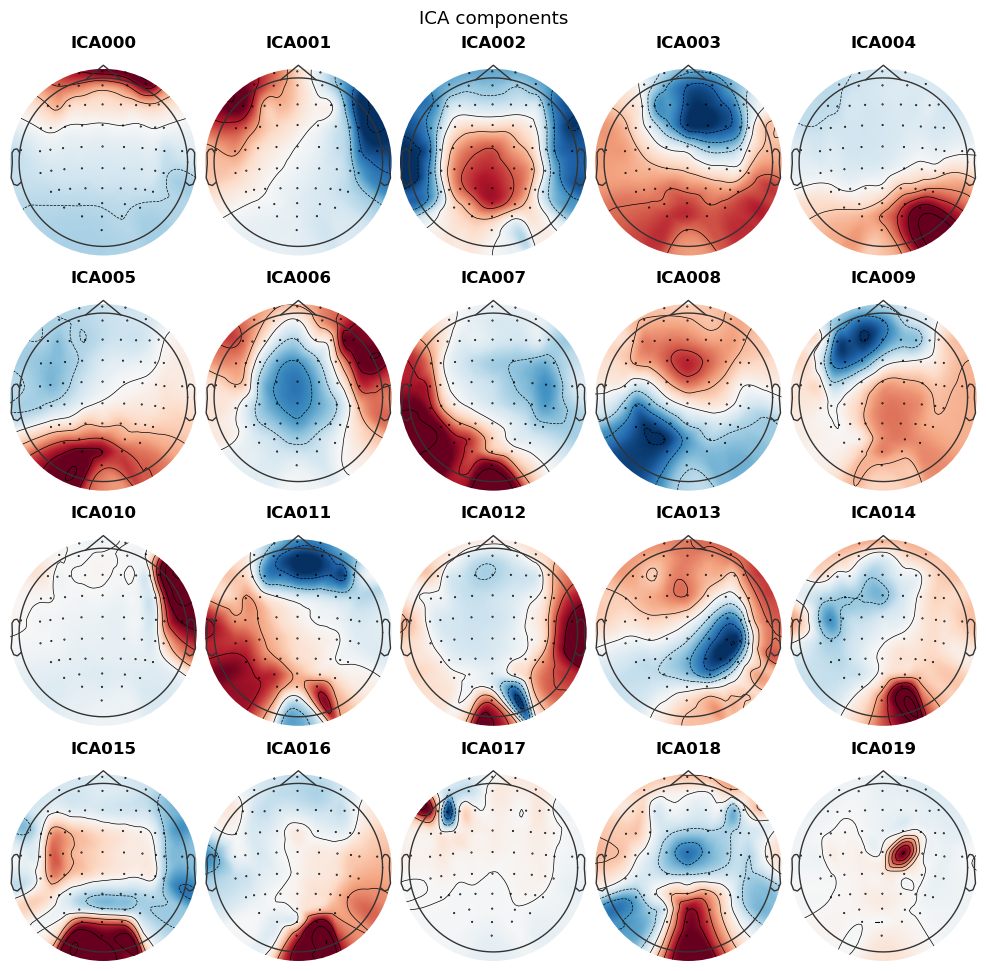

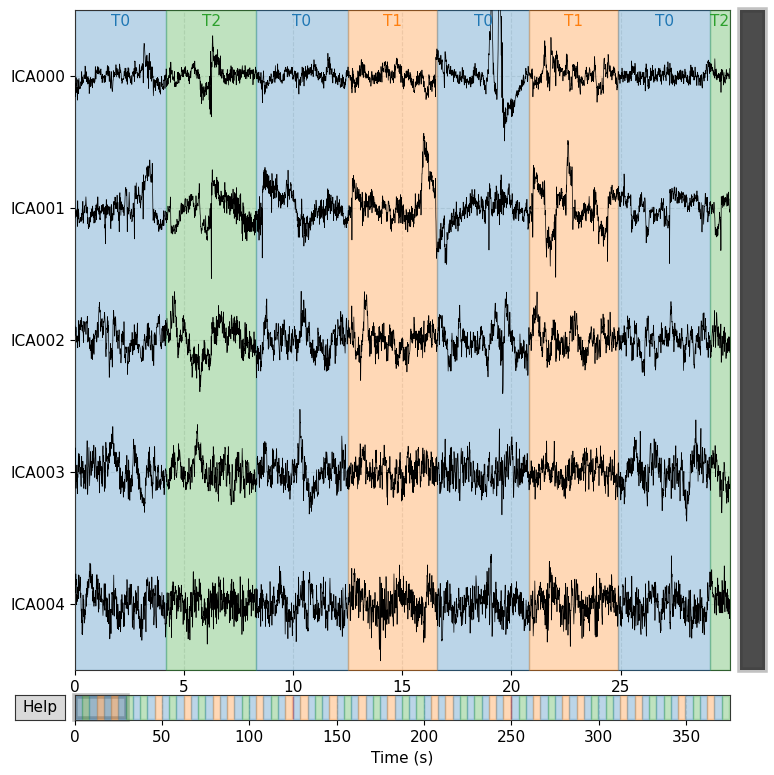

In [46]:
from mne.preprocessing import ICA

raw_filt.set_eeg_reference('average', projection=True)
raw_filt.apply_proj()

ica = ICA(n_components=20, method='fastica', random_state=42, max_iter=800)
ica.fit(raw_filt)

# Inspect for eye-blink components (typically frontal, high kurtosis)
comp_fig = ica.plot_components(picks=range(20))
save_fig(comp_fig, 'ica_components.png')

src_fig = ica.plot_sources(raw_filt, picks=range(5), start=0, stop=30)
save_fig(src_fig, 'ica_sources.png')

Components `0` and `1` were identified as ocular artifacts by visual
inspection of the plots above (frontal topography, high-amplitude
low-frequency bursts matching blinks). Re-inspect and update
`ica.exclude` below if you change the subject or runs.

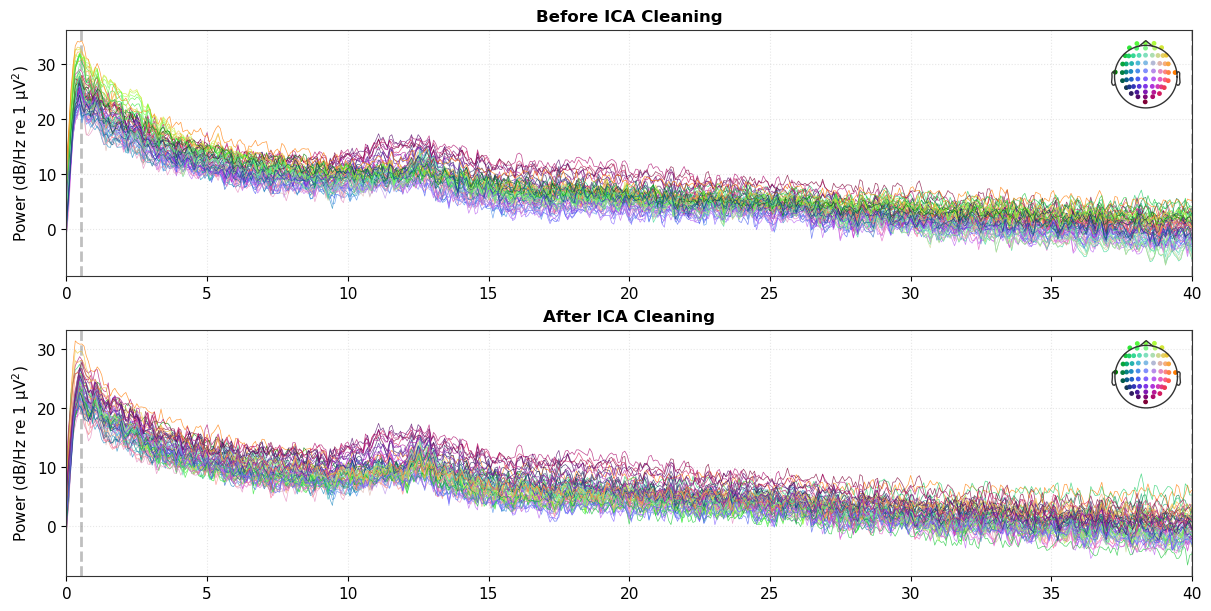

Removed 2 ICA component(s): [0, 1]


In [47]:
ica.exclude = [0, 1]
raw_clean = raw_filt.copy()
ica.apply(raw_clean)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
raw_filt.compute_psd(fmax=40, verbose=False).plot(axes=axes[0], show=False)
axes[0].set_title('Before ICA Cleaning')
raw_clean.compute_psd(fmax=40, verbose=False).plot(axes=axes[1], show=False)
axes[1].set_title('After ICA Cleaning')
save_fig(fig, 'psd_before_after_ica.png')
plt.show()

print(f"Removed {len(ica.exclude)} ICA component(s): {ica.exclude}")

## 6. Epoching

In [48]:
# `epochs` is used throughout the rest of the notebook and must be built
# from the cleaned continuous recording before any of the sections below.
events, event_id = mne.events_from_annotations(raw_clean)
print("Event counts:", {label: int((events[:, 2] == code_).sum())
                         for label, code_ in event_id.items()})

epochs = mne.Epochs(raw_clean, events, event_id=event_id,
                     tmin=-1.0, tmax=4.0, baseline=None,
                     picks='eeg', preload=True)
print(epochs)

Event counts: {np.str_('T0'): 45, np.str_('T1'): 23, np.str_('T2'): 22}
<Epochs | 87 events (all good), -1 – 4 s (baseline off), ~34.1 MiB, data loaded,
 np.str_('T0'): 42
 np.str_('T1'): 23
 np.str_('T2'): 22>


## 7. Event-Related (De)synchronization — ERD/ERS

Percent power change from a pre-stimulus baseline (-1-0 s) to the imagery
window (1-4 s). Expect **contralateral** ERD: left-hand imagery should
desynchronize right-sensorimotor channels, and vice versa.

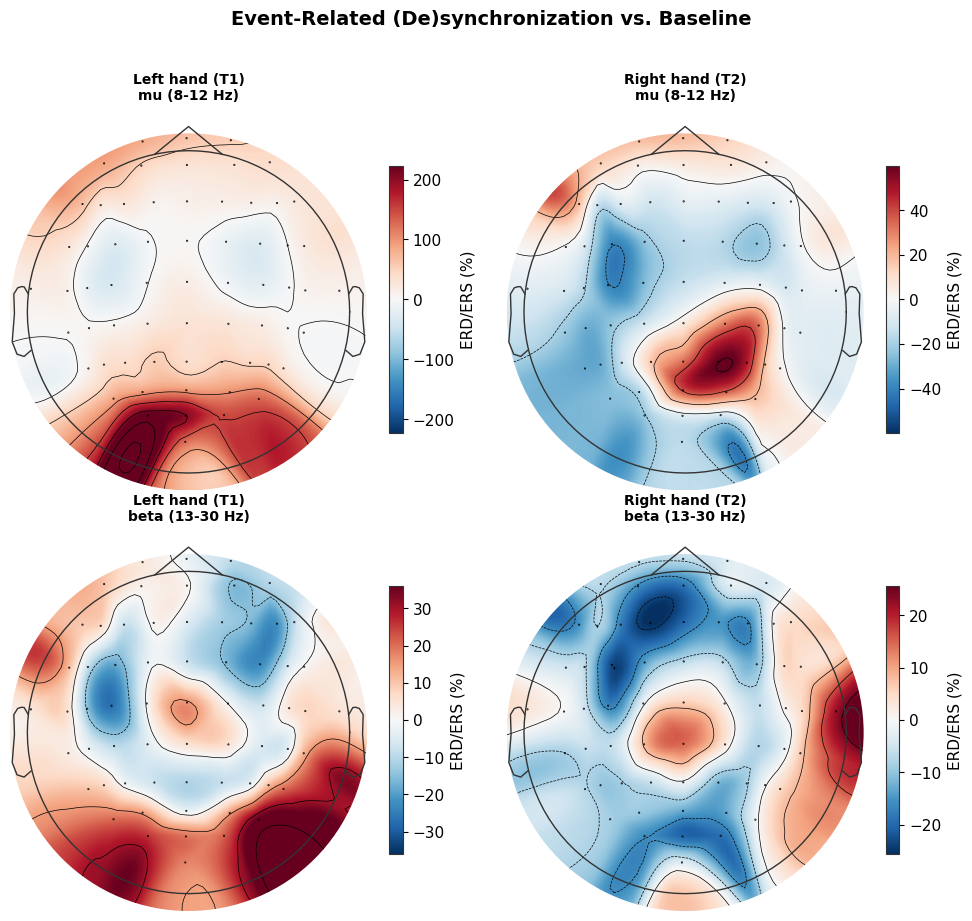

In [49]:
bands = {'mu (8-12 Hz)': (8, 12), 'beta (13-30 Hz)': (13, 30)}
conditions = {'Left hand (T1)': epochs['T1'], 'Right hand (T2)': epochs['T2']}

def compute_band_power(epochs_obj, fmin, fmax):
    psd = epochs_obj.compute_psd(method='multitaper', fmin=fmin, fmax=fmax, verbose=False)
    return psd.get_data().mean(axis=(0, 2))

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for col, (cond_label, ep) in enumerate(conditions.items()):
    base_ep = ep.copy().crop(-1.0, 0.0)
    task_ep = ep.copy().crop(1.0, 4.0)
    for row, (band_label, (fmin, fmax)) in enumerate(bands.items()):
        p_base = compute_band_power(base_ep, fmin, fmax)
        p_task = compute_band_power(task_ep, fmin, fmax)
        erd = (p_task - p_base) / p_base * 100

        ax = axes[row, col]
        im, _ = mne.viz.plot_topomap(erd, ep.info, axes=ax, cmap='RdBu_r',
                                      vlim=(-np.abs(erd).max(), np.abs(erd).max()),
                                      show=False)
        ax.set_title(f'{cond_label}\n{band_label}', fontsize=10)
        plt.colorbar(im, ax=ax, shrink=0.7, label='ERD/ERS (%)')

fig.suptitle('Event-Related (De)synchronization vs. Baseline', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
save_fig(fig, 'erd_ers_topomaps.png')
plt.show()

## 8. CSP + LDA Classification (Static Window)

Accuracy per fold : ['77.78%', '100.00%', '77.78%', '66.67%', '88.89%']
Mean CV accuracy  : 82.22% ± 11.33%

Aggregated classification report (all folds):
              precision    recall  f1-score   support

   Left (T1)       0.80      0.87      0.83        23
  Right (T2)       0.85      0.77      0.81        22

    accuracy                           0.82        45
   macro avg       0.82      0.82      0.82        45
weighted avg       0.82      0.82      0.82        45



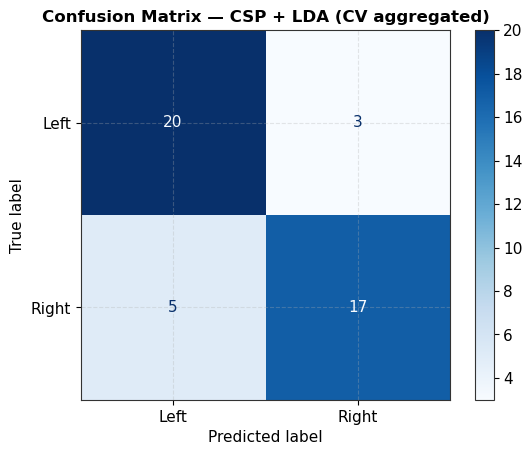

In [50]:
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

epochs_motor = epochs['T1', 'T2'].copy()
epochs_motor.filter(8.0, 12.0, fir_design='firwin', verbose=False)
epochs_motor.crop(tmin=1, tmax=2.5)

X = epochs_motor.get_data()
y = np.where(epochs_motor.events[:, -1] == epochs_motor.event_id['T1'], 0, 1)  # 0 = left, 1 = right

csp = CSP(n_components=6, reg='ledoit_wolf', log=True, norm_trace=False)
lda = LDA()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_scores, all_y_true, all_y_pred = [], [], []
for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    csp.fit(X_train, y_train)
    X_train_csp = csp.transform(X_train)
    X_test_csp = csp.transform(X_test)

    lda.fit(X_train_csp, y_train)
    y_pred = lda.predict(X_test_csp)

    fold_scores.append(lda.score(X_test_csp, y_test))
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

print(f"Accuracy per fold : {[f'{s:.2%}' for s in fold_scores]}")
print(f"Mean CV accuracy  : {np.mean(fold_scores):.2%} ± {np.std(fold_scores):.2%}")
print("\nAggregated classification report (all folds):")
print(classification_report(all_y_true, all_y_pred, target_names=['Left (T1)', 'Right (T2)']))

cm = confusion_matrix(all_y_true, all_y_pred)
cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Left', 'Right'])
cm_disp.plot(cmap='Blues')
plt.title('Confusion Matrix — CSP + LDA (CV aggregated)')
save_fig(cm_disp.figure_, 'csp_confusion_matrix.png')
plt.show()

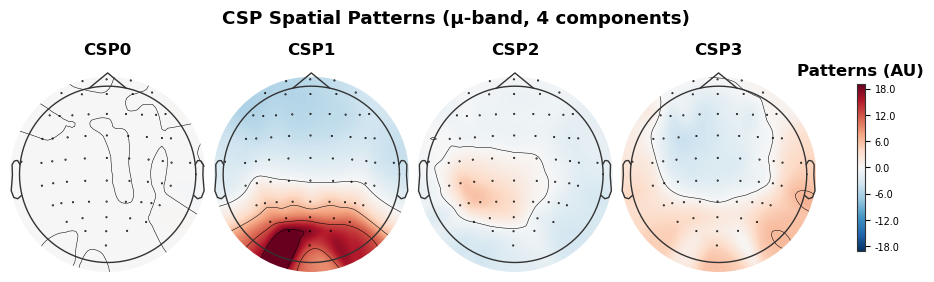

In [51]:
# Fit on all available data purely to visualize spatial patterns -- this
# fit is NOT used for the accuracy figures above.
csp_viz = CSP(n_components=4, reg='ledoit_wolf', log=True)
csp_viz.fit(X, y)
patterns_fig = csp_viz.plot_patterns(epochs_motor.info, ch_type='eeg', components=range(4),
                                      units='Patterns (AU)', size=1.5, show=False)
patterns_fig.suptitle('CSP Spatial Patterns (μ-band, 4 components)', y=1.05, fontweight='bold')
save_fig(patterns_fig, 'csp_spatial_patterns.png')
plt.show()

## 9. Time-Resolved Decoding (Sliding Window)

Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 3e-05 (2.2e-16 eps * 64 dim * 2.1e+09  max singular value)
    Estimated rank (data): 53
    Using tolerance 2.7e-05 (2.2e-16 eps * 64 dim * 1.9e+09  max singular value)
    data: rank 53 computed from 64 data channels with 0 projectors
    Estimated rank (data): 53
    data: rank 53 computed from 64 data channels with 0 projectors
    Using tolerance 2.9e-05 (2.2e-16 eps * 64 dim * 2.1e+09  max singular value)
    Estimated rank (data): 53
    data: rank 53 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 53
Estimating class=0 covariance using LEDOIT_WOLF
Reducing data rank from 64 -> 53
Estimating class=0 covariance using LEDO

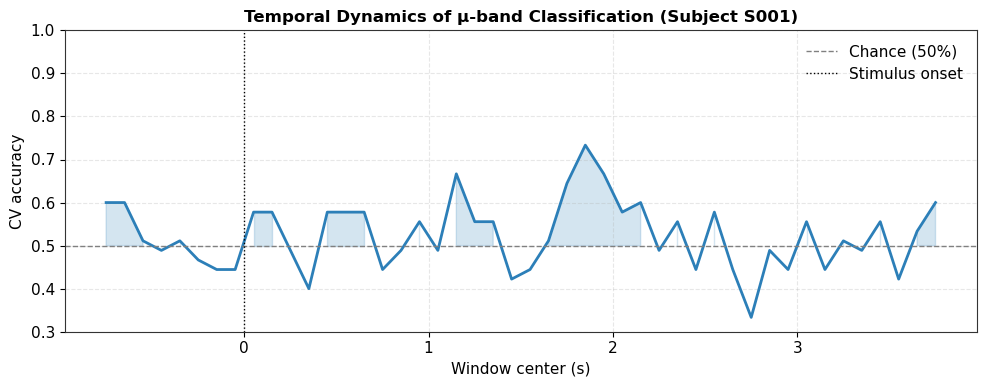

Peak accuracy: 73.33% at t = 1.85 s


In [52]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

FREQ_BAND = (8, 12)
WIN_SIZE = 0.5   # seconds
WIN_STEP = 0.1   # seconds
SFREQ = epochs.info['sfreq']

epochs_t1t2 = epochs['T1', 'T2'].copy()
epochs_t1t2.filter(*FREQ_BAND, fir_window='hamming', verbose=False)

X_full = epochs_t1t2.get_data()
y = np.where(epochs_t1t2.events[:, 2] == epochs_t1t2.event_id['T1'], 0, 1)

times = epochs_t1t2.times
win_samples = int(WIN_SIZE * SFREQ)
step_samples = int(WIN_STEP * SFREQ)

win_starts = np.arange(0, X_full.shape[2] - win_samples + 1, step_samples)
win_centers = times[win_starts + win_samples // 2]

pipeline = Pipeline([
    ('csp', CSP(n_components=4, reg='ledoit_wolf', log=True)),
    ('lda', LDA())
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

window_scores = []
for start in win_starts:
    X_win = X_full[:, :, start:start + win_samples]
    score = cross_val_score(pipeline, X_win, y, cv=cv, scoring='accuracy', n_jobs=-1).mean()
    window_scores.append(score)
window_scores = np.array(window_scores)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(win_centers, window_scores, color=PRIMARY_COLOR, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance (50%)')
ax.axvline(0, color='black', linestyle=':', linewidth=1, label='Stimulus onset')
ax.fill_between(win_centers, 0.5, window_scores, where=window_scores > 0.5,
                 alpha=0.2, color=PRIMARY_COLOR)
ax.set_xlabel('Window center (s)')
ax.set_ylabel('CV accuracy')
ax.set_title(f'Temporal Dynamics of μ-band Classification (Subject S{SUBJECT:03d})')
ax.legend()
ax.set_ylim(0.3, 1.0)
fig.tight_layout()
save_fig(fig, 'decoding_time_resolved.png')
plt.show()

best_idx = int(np.argmax(window_scores))
print(f"Peak accuracy: {window_scores[best_idx]:.2%} at t = {win_centers[best_idx]:.2f} s")

## 10. Summary & Key Findings

Pulled directly from the variables computed above, so this stays accurate
whenever the notebook is re-run (e.g. with a different subject).

EEG MOTOR IMAGERY ANALYSIS — SUMMARY

Subject: S001   |   Runs used: [4, 8, 12]
Recording: 6.2 min at 160 Hz, 64 EEG channels

--- Preprocessing ---
Channels interpolated (outlier screening): ['Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'FT8', 'T8', 'T10', 'TP8']
ICA components removed (ocular artifacts): [0, 1]

--- Epochs ---
  T0: 42 trials
  T1: 23 trials
  T2: 22 trials

--- Classification performance (mu-band CSP + LDA, 1.0-2.5 s window) ---
  Mean 5-fold CV accuracy : 82.2% ± 11.3%  (chance = 50%)
  Peak time-resolved acc. : 73.3% at t = 1.85s



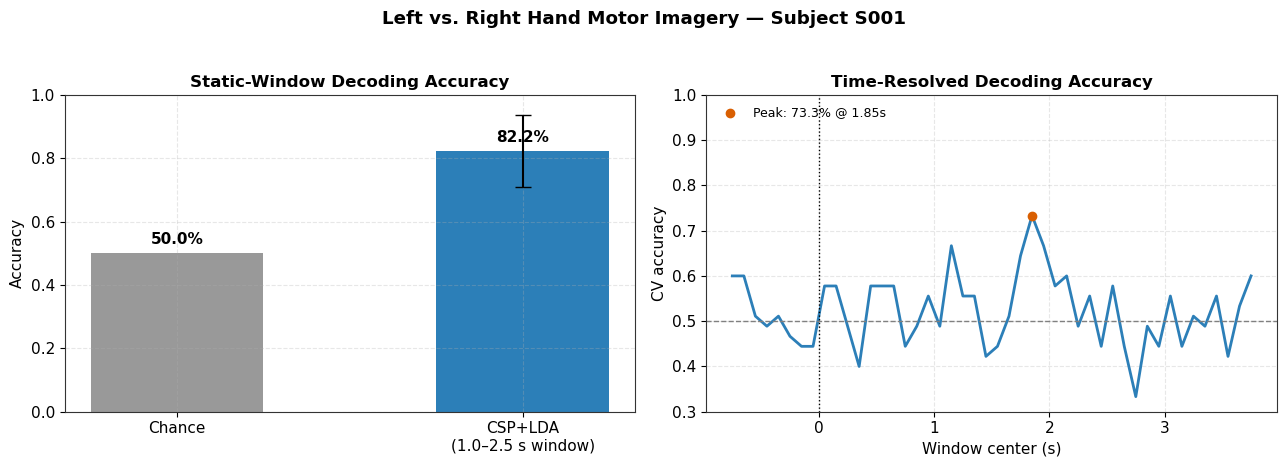

In [53]:
print("=" * 60)
print("EEG MOTOR IMAGERY ANALYSIS — SUMMARY")
print("=" * 60)

print(f"\nSubject: S{SUBJECT:03d}   |   Runs used: {RUNS}")
print(f"Recording: {raw.times[-1]/60:.1f} min at {raw.info['sfreq']:.0f} Hz, {len(raw.ch_names)} EEG channels")

print("\n--- Preprocessing ---")
print(f"Channels interpolated (outlier screening): {bads or 'none'}")
print(f"ICA components removed (ocular artifacts): {ica.exclude}")

print("\n--- Epochs ---")
for label, code_ in epochs.event_id.items():
    print(f"  {label}: {(epochs.events[:, 2] == code_).sum()} trials")

print("\n--- Classification performance (mu-band CSP + LDA, 1.0-2.5 s window) ---")
print(f"  Mean 5-fold CV accuracy : {np.mean(fold_scores):.1%} ± {np.std(fold_scores):.1%}  (chance = 50%)")
print(f"  Peak time-resolved acc. : {window_scores[best_idx]:.1%} at t = {win_centers[best_idx]:.2f}s")
print("\n" + "=" * 60)

# --- Summary dashboard figure ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: static-window accuracy vs. chance
ax = axes[0]
bar_labels = ['Chance', 'CSP+LDA\n(1.0–2.5 s window)']
bar_values = [0.5, np.mean(fold_scores)]
bar_colors = ['#999999', PRIMARY_COLOR]
bars = ax.bar(bar_labels, bar_values, color=bar_colors, width=0.5)
ax.errorbar(1, np.mean(fold_scores), yerr=np.std(fold_scores), fmt='none',
            ecolor='black', capsize=6)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Static-Window Decoding Accuracy')
for bar, val in zip(bars, bar_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.03, f'{val:.1%}',
            ha='center', fontweight='bold')

# Right: time-resolved decoding curve with peak highlighted
ax = axes[1]
ax.plot(win_centers, window_scores, color=PRIMARY_COLOR, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linestyle=':', linewidth=1)
ax.scatter([win_centers[best_idx]], [window_scores[best_idx]], color=ACCENT_COLOR, zorder=5,
           label=f'Peak: {window_scores[best_idx]:.1%} @ {win_centers[best_idx]:.2f}s')
ax.set_xlabel('Window center (s)')
ax.set_ylabel('CV accuracy')
ax.set_title('Time-Resolved Decoding Accuracy')
ax.set_ylim(0.3, 1.0)
ax.legend(loc='upper left', fontsize=9)

fig.suptitle(f'Left vs. Right Hand Motor Imagery — Subject S{SUBJECT:03d}', fontweight='bold', y=1.03)
fig.tight_layout()
save_fig(fig, 'summary_dashboard.png')
plt.show()

**Takeaway:** decoding accuracy rises above chance during the imagery
window and peaks a couple of seconds after cue onset, consistent with
contralateral mu/beta ERD in sensorimotor cortex.